<a href="https://colab.research.google.com/github/Shashikala-s/into-LLM/blob/main/ML%20Estimation%20(Normal%20Distribution).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ML-estimation**

In [87]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [88]:
n_obs=10000
true_location=0 #mean of normal
true_dist=torch.distributions.Normal(loc=true_location, scale=1.0)
train_data=true_dist.sample([n_obs])

In [89]:
empirical_mean=torch.mean(train_data)
print(empirical_mean.item())

-0.005449838470667601


<function matplotlib.pyplot.show(close=None, block=None)>

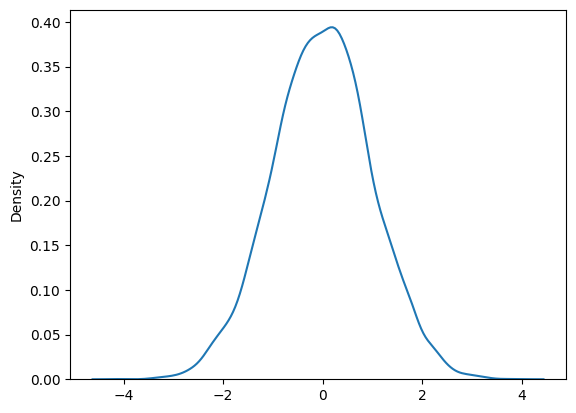

In [90]:
sns.kdeplot(train_data)
plt.show

# **Optimizing a parameter: gradients, optimizers, loss & backprop**

In [91]:
location =torch.tensor(1.0, requires_grad=True, dtype=torch.float64)
print(location)


tensor(1., dtype=torch.float64, requires_grad=True)


In [92]:
learning_rate = 0.0000001
opt=torch.optim.SGD([location], lr=learning_rate)


In [93]:
#compute predictions for current prameter values

prediction =torch.distributions.Normal(loc=location, scale=1.0)

In [94]:
#compute the loss for the current prediction
loss=-torch.sum(prediction.log_prob(train_data))
print(loss)

tensor(19168.4863, grad_fn=<NegBackward0>)


In [95]:
#backpropagate the error signal
print(location.item())
print(location.grad)


1.0
None


In [96]:
loss.backward()
print(location.item())
print(location.grad)

1.0
tensor(10054.4980, dtype=torch.float64)


In [97]:
#update the parameter
opt.step()
print(location.item())
print(location.grad)

0.9989945501953125
tensor(10054.4980, dtype=torch.float64)


In [98]:
#reset gradiant information
opt.zero_grad()
print(location.item())
print(location.grad)

0.9989945501953125
None


# **Training loop**

In [99]:
n_training_steps = 10000
print("\n%5s %24s %15s %15s" % ("step", "loss", "estimate", "diff. target"))
for i in range(n_training_steps):
    prediction = torch.distributions.Normal(loc=location, scale=1.0)
    loss = -torch.sum(prediction.log_prob(train_data))
    loss.backward()
    if (i + 1) % 500 == 0:
        print(
            "%5d %24.3f %15.5f %15.5f"
            % (
                i + 1,
                loss.item(),
                location.item(),
                abs(location.item() - empirical_mean),
            )
        )
    opt.step()
    opt.zero_grad()


 step                     loss        estimate    diff. target
  500                15972.413         0.60423         0.60968
 1000                14797.229         0.36425         0.36970
 1500                14365.120         0.21873         0.22418
 2000                14206.234         0.13049         0.13594
 2500                14147.814         0.07698         0.08243
 3000                14126.333         0.04453         0.04998
 3500                14118.434         0.02486         0.03031
 4000                14115.530         0.01293         0.01838
 4500                14114.464         0.00569         0.01114
 5000                14114.068         0.00131         0.00676
 5500                14113.924        -0.00135         0.00410
 6000                14113.872        -0.00297         0.00248
 6500                14113.852        -0.00394         0.00151
 7000                14113.846        -0.00454         0.00091
 7500                14113.844        -0.00490        